<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/Algo_Naive_Bayes-DataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# Memuat dataset
df = pd.read_csv('https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/HEART%20ke%202.csv', sep=';')
df.head()

,age,trestbps,chol,thalach,target
0,63,145,233,150,1
1,37,130,250,187,1
2,41,130,204,172,1
3,56,120,236,178,1
4,57,120,354,163,1


In [10]:
# Pemeriksaan data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       303 non-null    int64
 1   trestbps  303 non-null    int64
 2   chol      303 non-null    int64
 3   thalach   303 non-null    int64
 4   target    303 non-null    int64
dtypes: int64(5)
memory usage: 12.0 KB


In [11]:
# Mengecek nilai yang hilang (null values)
df.isna().sum()

,0
age,0
trestbps,0
chol,0
thalach,0
target,0


In [12]:
# Melihat dimensi dataframe (baris, kolom)
df.shape

(303, 5)

In [13]:
# Statistik deskriptif data
df.describe()

,age,trestbps,chol,thalach,target
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,0.544554
std,9.082101,17.538143,51.830751,22.905161,0.498835
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,1.000000
75%,61.000000,140.000000,274.500000,166.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,1.000000


In [14]:
# Melihat nilai unik pada kolom target 'Grade'
df['target'].unique()

array([1, 0])

In [15]:
# Encoding data kategori menjadi numerik
en = LabelEncoder()
df['target'] = en.fit_transform(df['target'])

# Menampilkan hasil setelah encoding
df.head()

,age,trestbps,chol,thalach,target
0,63,145,233,150,1
1,37,130,250,187,1
2,41,130,204,172,1
3,56,120,236,178,1
4,57,120,354,163,1


In [16]:
# Melihat pemetaan label setelah di-encode
label_mapping = pd.Series(en.classes_)
label_mapping

,0
0,0
1,1


In [17]:
# Memisahkan fitur (x) dan target (y)
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [18]:
# Menampilkan isi x dan y
x

array([[ 63, 145, 233, 150],
       [ 37, 130, 250, 187],
       [ 41, 130, 204, 172],
       ...,
       [ 68, 144, 193, 141],
       [ 57, 130, 131, 115],
       [ 57, 130, 236, 174]])

In [19]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
# Membagi data menjadi Training Set dan Test Set (25% untuk testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=50)

# Menampilkan jumlah data masing-masing subset
print("x_train =", len(x_train))
print("x_test =", len(x_test))
print("y_train =", len(y_train))
print("y_test =", len(y_test))

x_train = 242
x_test = 61
y_train = 242
y_test = 61


In [21]:
# Membuat dataframe sementara untuk melihat data testing dan nilai aktualnya
test_df = pd.DataFrame(x_test, columns=df.columns[:-1])
test_df['Actual'] = y_test
test_df

,age,trestbps,chol,thalach,Actual
0,64,140,313,133,1
1,41,135,203,132,1
2,46,120,249,144,0
3,65,160,360,151,1
4,57,124,261,141,0
...,...,...,...,...,...
56,40,152,223,181,0
57,50,120,219,158,1
58,40,110,167,114,0
59,39,94,199,179,1


In [22]:
# Standarisasi fitur menggunakan StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Menampilkan x_train yang sudah di-scaling
x_train

array([[ 0.9017602 , -0.07513226,  0.19304792, -0.11765029],
       [-0.39527379, -1.8518757 , -0.46091669, -0.29099198],
       [-1.15187694, -0.66738007, -0.37917112,  0.83572895],
       [ 0.68558787,  0.9909138 , -0.84920818,  0.48904559],
       [ 1.11793253,  0.39866599,  0.76526696,  1.05240606],
       [-1.25996311, -0.96350398,  1.19443124,  1.355754  ],
       [ 0.5775017 , -0.66738007, -1.36011804, -2.32775673],
       [-0.07101529, -0.37125617,  0.58133941,  0.09902681],
       [ 1.22601869,  2.76765723, -0.33829833,  0.66238727],
       [ 0.14515704, -0.07513226,  0.78570335, -2.02440879],
       [ 0.36132937, -0.66738007,  0.80613975,  0.44571017],
       [-0.50335995,  0.51711555, -0.23611636,  0.57571643],
       [ 0.9017602 ,  1.10936336,  3.31981623,  0.18569765],
       [-1.15187694,  0.51711555, -0.19524357,  1.31241858],
       [ 0.03707087, -0.07513226,  0.35653908,  0.22903307],
       [ 0.14515704, -0.66738007, -0.17480717,  1.22574774],
       [ 1.33410486,  1.

In [23]:
# Inisialisasi dan melatih model Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

In [24]:
# Melakukan prediksi pada data testing
y_pred = nb.predict(x_test)

In [25]:
# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[17  8]
 [10 26]]


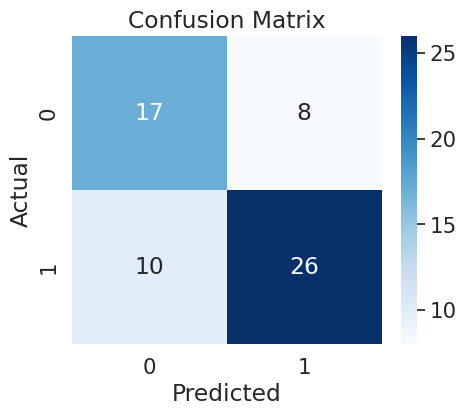

In [26]:
# Visualisasi Confusion Matrix dengan Heatmap
plt.figure(figsize=(5,4))
sns.set(font_scale=1.4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=en.classes_, yticklabels=en.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Menampilkan Classification Report (Precision, Recall, F1-Score)
creport = classification_report(y_test, y_pred)
print(creport)

              precision    recall  f1-score   support

           0       0.63      0.68      0.65        25
           1       0.76      0.72      0.74        36

    accuracy                           0.70        61
   macro avg       0.70      0.70      0.70        61
weighted avg       0.71      0.70      0.71        61



In [28]:
# Menghitung dan menampilkan Tingkat Akurasi
akurasi = accuracy_score(y_test, y_pred)
print("Tingkat Akurasi : %d persen"%(akurasi*100))

Tingkat Akurasi : 70 persen


In [29]:
# Menghitung jumlah kemunculan nilai aktual dan prediksi
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

In [30]:
# Menampilkan hasil perhitungan jumlah aktual
actual_counts

,count
0,25
1,36


In [31]:
predicted_counts

,count
0,27
1,34


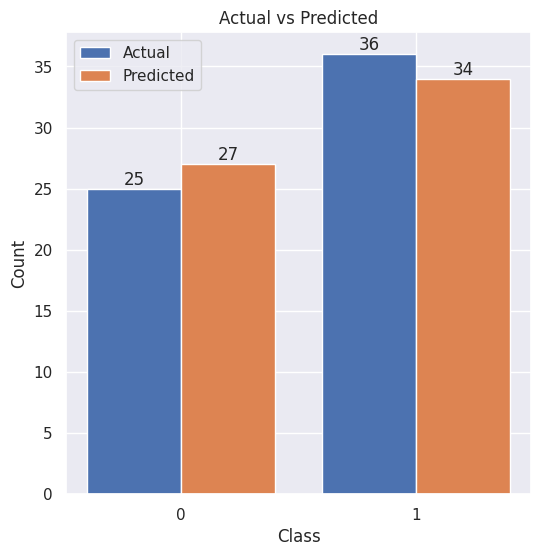

In [32]:
# Membuat visualisasi perbandingan Actual vs Predicted
plt.figure(figsize=(6, 6))
sns.set(font_scale=1)
width = 0.4
classes = range(len(en.classes_))

# Plot batang untuk data Aktual
bars1 = plt.bar(classes, actual_counts, width, label='Actual')

# Plot batang untuk data Prediksi (digeser sedikit agar tidak menumpuk)
bars2 = plt.bar([p + width for p in classes], predicted_counts, width, label='Predicted')

# Menambahkan label angka di atas setiap batang
plt.bar_label(bars1, fmt='%d')
plt.bar_label(bars2, fmt='%d')

# Pengaturan label dan judul grafik
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Actual vs Predicted')
plt.xticks([p + width/2 for p in classes], en.inverse_transform(classes))
plt.legend()

plt.show()

In [33]:
# Menambahkan kolom hasil prediksi ke dataframe test_df
test_df['Predicted'] = y_pred
test_df

,age,trestbps,chol,thalach,Actual,Predicted
0,64,140,313,133,1,0
1,41,135,203,132,1,1
2,46,120,249,144,0,1
3,65,160,360,151,1,0
4,57,124,261,141,0,0
...,...,...,...,...,...,...
56,40,152,223,181,0,1
57,50,120,219,158,1,1
58,40,110,167,114,0,1
59,39,94,199,179,1,1


In [34]:
# Menyimpan hasil akhir ke file Excel
test_df.to_excel('data_test.xlsx', index=False)